# Importing Dependencies

In [5]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

# Defining Variables

$S_0$: Initial asset price

$T$: Time horizon

$n$: Number of time steps

$\Delta t$: Time increment for each step $\Delta t = \frac{T}{n}$

$\mu$: Mean return (drift component)

$\lambda$: Jump intensity (controls rate of jumps)

$\mu_j$: Mean of log jump

$\sigma_j$: Standard deviation of log Jump

$\rho$: Correlation coefficient for $\varepsilon$'s

$\kappa$: Volatility mean reversion rate (higher $\implies$ Faster)

$\theta$: Mean volatility level

$\xi$: Volatility of volatility

In [6]:
num_paths = 100
n = 252
T = 1
dt = T / n
S0 = 100
theta = 0.05
kappa = 6
xi = 0.4
rho = -0.7
mu = 0.03
lam = 1
mu_j = 0.05
sigma_j = 0.05

#Simulating Paths

**Correlated Brownian Motion for Stochastic Volatility:**
$$\varepsilon_{S_{i,j}} \sim \mathbf{N}(0, 1)$$

$$\varepsilon_{v_{i,j}} = \rho \varepsilon_{S_{i,j}} + \sqrt{1 - \rho^2} Z_{i,j} \quad \text{where} \quad Z_{i,j} \sim \mathbf{N}(0, 1)$$

**Jump Component:**
$$\Delta N_{i,j} \sim \text{Poisson}(\lambda \Delta t)$$

$$Y_{i,j} \sim \mathbf{N}(\mu_j \Delta N_{i,j}, \sigma_j^2 \Delta N_{i,j})$$

Expected relative jump size (compensation term) given by,

$$k = e^{\mu_j + \frac{1}{2}\sigma_j^2} - 1$$

**Discrete Time Stochastic Volatility Process:**

$$v_{i+1, j} = v_{i, j} + \kappa \left( \theta - \max(v_{i, j}, 0) \right) \Delta t + \xi \sqrt{\max(v_{i, j}, 0)} \sqrt{\Delta t} \varepsilon_{v_{i,j}}$$

**Discrete Time Asset Price Process:**
$$S_{i+1, j} = S_{i, j} + S_{i, j} (\mu - \lambda k) \Delta t + \sqrt{\max(v_{i, j}, 0)} S_{i, j} \sqrt{\Delta t} \varepsilon_{S_{i,j}} + S_{i, j} \left( e^{Y_{i, j}} - 1 \right)$$

For time step $i \in \{0, 1, \dots, n-1\}$ and across paths $j \in \{1, 2, \dots, \text{num_paths}\}$

In [7]:
def Bates(S0:float,n:int,dt:float,theta:float,kappa:float,xi:float,rho:float,mu:float,lam:float,mu_j:float,sigma_j:float,num_paths:int)->np.ndarray:
  epsilon_S = np.random.normal(0,1,(n,num_paths))
  epsilon_v = rho * epsilon_S + np.sqrt(1 - rho ** 2) * np.random.normal(0,1,(n,num_paths))

  v = np.zeros((n + 1, num_paths))
  v[0,:] = theta

  S = np.zeros((n + 1, num_paths))
  S[0, :] = S0

  k = np.exp(mu_j+0.5*sigma_j**2)-1
  dN = np.random.poisson(lam*dt,size=(n,num_paths))
  Y = np.random.normal(loc=mu_j * dN,scale=sigma_j * np.sqrt(dN),size=(n,num_paths))

  for i in range(0,n):
    v[i+1] = v[i] + kappa * (theta - np.maximum(v[i],0)) * dt + xi * np.sqrt(np.maximum(v[i], 0)) * np.sqrt(dt) * epsilon_v[i]
    S[i+1] = S[i] + S[i] * (mu-lam*k) * dt + np.sqrt(np.maximum(v[i],0)) * S[i] * np.sqrt(dt) * epsilon_S[i] + S[i] * (np.exp(Y[i])-1)

  return S

# Plotting Paths

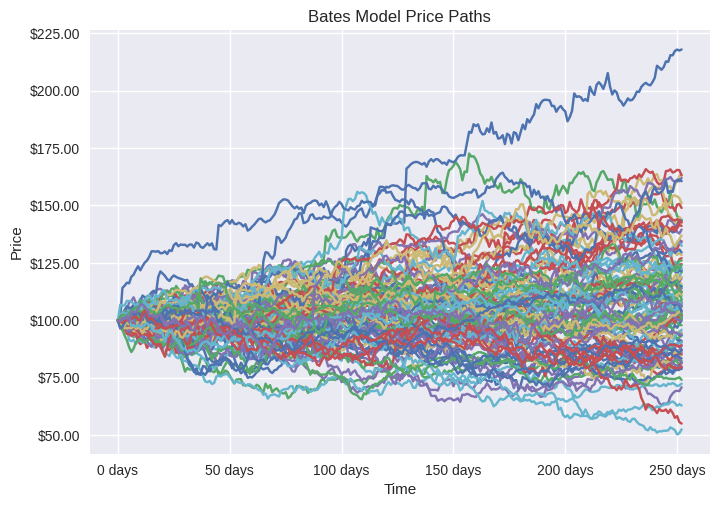

In [8]:
paths = Bates(S0,n,dt,theta,kappa,xi,rho,mu,lam,mu_j,sigma_j,num_paths)

plt.plot(paths)
plt.grid(True)
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Bates Model Price Paths")
plt.gca().yaxis.set_major_formatter("${x:,.2f}")
plt.gca().xaxis.set_major_formatter("{x:,.0f} days")
plt.show()